In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
df = pd.read_csv('v3_master_combined.csv')


In [ ]:
df.info()


In [ ]:
df.isnull().sum()


In [67]:
# from data_profiling import ProfileReport

# profile= ProfileReport(df)

# profile.to_file('report.html')


In [ ]:
df = df.drop('Brand Name',axis=1)


In [5]:
df = df.drop_duplicates()


In [6]:
df = df.drop(columns=['Total_Sale_Normalized'])


In [7]:
df = df.dropna(subset=['Total Sale'])


In [ ]:
df.isnull().sum()


In [74]:
df= df.drop(columns=['Dataset'])

df = df.sort_values(["Branch Name", "Date"])

# Lag features per branch
df["sales_lag_1"] = df.groupby("Branch Name")["Total Sale"].shift(1)
df["sales_lag_7"] = df.groupby("Branch Name")["Total Sale"].shift(7)

# Rolling averages per branch (shifted to avoid leakage - only past data)
df["sales_roll_7_mean"] = (
    df.groupby("Branch Name")["Total Sale"]
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(0, drop=True)
)
df["sales_roll_30_mean"] = (
    df.groupby("Branch Name")["Total Sale"]
    .shift(1)
    .rolling(30)
    .mean()
    .reset_index(0, drop=True)
)

# Day-of-week average per branch (captures "this branch usually sells more on Fridays")
dow_avg = df.groupby(["Branch Name", "Day_of_Week"])["Total Sale"].transform(
    lambda x: x.shift(1).expanding().mean()
)
df["branch_dow_avg"] = dow_avg


df = df.dropna(
    subset=["sales_lag_1", "sales_lag_7", "sales_roll_7_mean", "sales_roll_30_mean"]
)


In [29]:
df = df[df["Date"].dt.year >= 2020].copy()
df = df.sort_values(["Branch Name", "Date"]).reset_index(drop=True)

print(df["Date"].dt.year.value_counts().sort_index())
print("Remaining branches:", df["Branch Name"].nunique())


Date
2020      300
2021     8296
2022    11014
2023    14107
2024    14930
2025     8280
Name: count, dtype: int64
Remaining branches: 57


In [33]:
df['Date']= pd.to_datetime(df['Date'])


In [ ]:
df.sample(10)


In [34]:
from sklearn.ensemble import RandomForestRegressor

X = df.select_dtypes(include = np.number).drop(columns=['Total Sale'])

y = df['Total Sale']


rf= RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1)
rf.fit(X,y)


corr_matrix = X.corr().abs()




upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))



to_drop =  [column for  column in upper.columns if any (upper[column] > 0.95)]


print("Coumns to drop",to_drop)

X_reduced = X.drop(columns = to_drop)
print("Remaining Shapes",X_reduced)





Coumns to drop ['working', 'unemployed', 'non-white', 'Transport_Accessibility_Score', 'distance_to_nearest_station_mi']
Remaining Shapes        population  households  avg_household_income  unemployment_rate  \
0             686         548            13716.9812              0.430   
1             686         548            13716.9812              0.430   
2             686         548            13716.9812              0.430   
3             686         548            13716.9812              0.430   
4             686         548            13716.9812              0.430   
...           ...         ...                   ...                ...   
56922         345         168            36481.0000              0.086   
56923         345         168            36481.0000              0.086   
56924         345         168            36481.0000              0.086   
56925         345         168            36481.0000              0.086   
56926         345         168            36481.0

In [35]:
X = X_reduced


In [36]:
print(df["Inferred_Brand"].nunique(), df["Branch Name"].nunique())


df = df.drop(columns=["postcode", "outercode"])


6 57


KeyError: "['postcode', 'outercode'] not found in axis"

In [13]:
%pip install category_encoders

from category_encoders import TargetEncoder






Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import xgboost as xgb

from sklearn.metrics import mean_absolute_error


color_pal = sns.color_palette()

plt.style.use("fivethirtyeight")




In [37]:

split_date = df['Date'].quantile(0.8,interpolation='nearest')

train = df[df['Date'] < split_date].copy()

test = df[df["Date"] >= split_date].copy()

print(f"Train: {train['Date'].min()} to {train['Date'].max()} ({len(train)} rows)")
print(f"Test: {test['Date'].min()} to {test['Date'].max()} ({len(test)} rows)")



Train: 2020-01-01 00:00:00 to 2024-10-12 00:00:00 (45509 rows)
Test: 2024-10-13 00:00:00 to 2025-06-30 00:00:00 (11418 rows)


In [38]:
X_train = train.drop(columns=['Total Sale','Date'])

y_train = train['Total Sale']

X_test = test.drop(columns=['Total Sale','Date'])
y_test = test['Total Sale']


encoder = TargetEncoder(cols=["Branch Name"])
X_train["Branch Name"] = encoder.fit_transform(X_train["Branch Name"], y_train)
X_test["Branch Name"] = encoder.transform(X_test["Branch Name"])


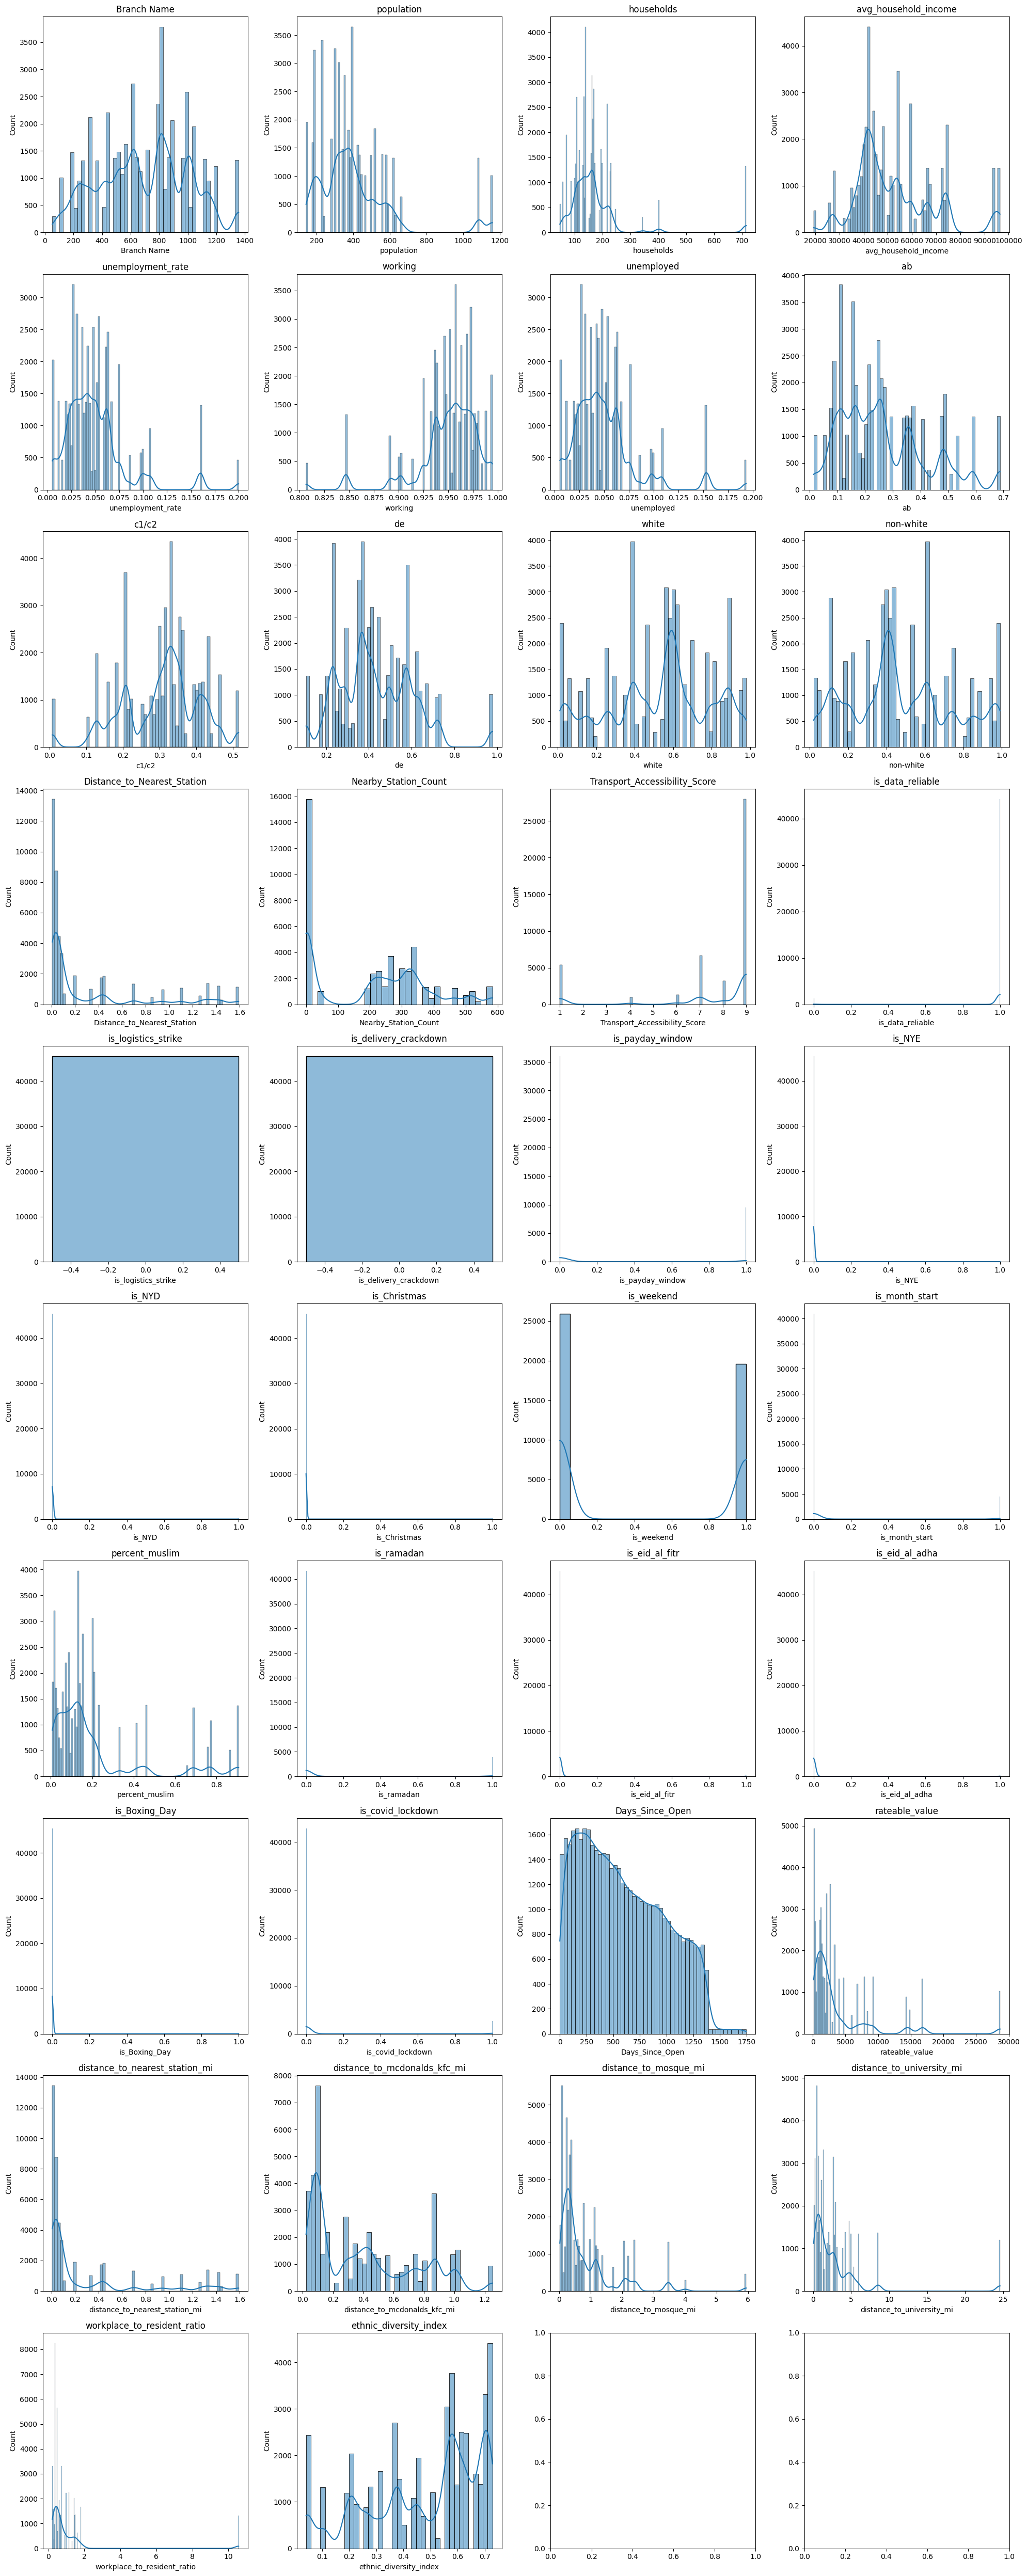

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

numeric_features = X_train.select_dtypes(include="number").columns

# Plot distributions
fig, axes = plt.subplots(
    nrows=(len(numeric_features) // 4) + 1,
    ncols=4,
    figsize=(20, 5 * ((len(numeric_features) // 4) + 1)),
)
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(X_train[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [16]:
skew_vals = X_train[numeric_features].apply(lambda x:skew(x.dropna()))


print(skew_vals.sort_values())


NameError: name 'numeric_features' is not defined

In [88]:
print(X_train["is_logistics_strike"].value_counts())
print(X_train["is_delivery_crackdown"].value_counts())


is_logistics_strike
0    50781
Name: count, dtype: int64
is_delivery_crackdown
0    50781
Name: count, dtype: int64


In [89]:
X_train = X_train.drop(columns=["is_logistics_strike", "is_delivery_crackdown"])

X_test = X_test.drop(columns=["is_logistics_strike", "is_delivery_crackdown"])


In [17]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy.stats import skew

numeric_features = X_train.select_dtypes(include="number").columns

# Drop constant columns first
constant_cols = [col for col in numeric_features if X_train[col].nunique() <= 1]
X_train = X_train.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)
numeric_features = [c for c in numeric_features if c not in constant_cols]

# Separate binary flags (0/1 only) from true continuous features
binary_cols = [
    col for col in numeric_features if X_train[col].dropna().isin([0, 1]).all()
]
continuous_cols = [col for col in numeric_features if col not in binary_cols]

print("Binary (not scaled):", binary_cols)
print("Continuous (to scale):", continuous_cols)

# Only compute skew + scale on continuous columns
skew_vals = X_train[continuous_cols].apply(lambda x: skew(x.dropna()))

standard_cols = skew_vals[abs(skew_vals) < 0.5].index.tolist()
robust_cols = skew_vals[abs(skew_vals) >= 0.5].index.tolist()

standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

X_train[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])

X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])


Binary (not scaled): ['is_data_reliable', 'is_payday_window', 'is_NYE', 'is_NYD', 'is_Christmas', 'is_weekend', 'is_month_start', 'is_ramadan', 'is_eid_al_fitr', 'is_eid_al_adha', 'is_Boxing_Day', 'is_covid_lockdown']
Continuous (to scale): ['Branch Name', 'population', 'households', 'avg_household_income', 'unemployment_rate', 'working', 'unemployed', 'ab', 'c1/c2', 'de', 'white', 'non-white', 'Distance_to_Nearest_Station', 'Nearby_Station_Count', 'Transport_Accessibility_Score', 'percent_muslim', 'Days_Since_Open', 'rateable_value', 'distance_to_nearest_station_mi', 'distance_to_mcdonalds_kfc_mi', 'distance_to_mosque_mi', 'distance_to_university_mi', 'workplace_to_resident_ratio', 'ethnic_diversity_index']


In [18]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
print("Categorical columns still present:", categorical_cols)

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns in case train/test have different categories present
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(
    "Any object columns left?", X_train.select_dtypes(include="object").columns.tolist()
)


Categorical columns still present: ['Day_of_Week', 'Nearest_Station_Type', 'Dataset', 'Inferred_Brand']
Any object columns left? []


In [95]:
print([c for c in X_train.columns if "lag" in c or "roll" in c])


['sales_lag_1', 'sales_lag_7', 'sales_roll_7_mean', 'sales_roll_30_mean']


In [19]:
nan_counts = X_train.isnull().sum()
print(nan_counts[nan_counts > 0])


Series([], dtype: int64)


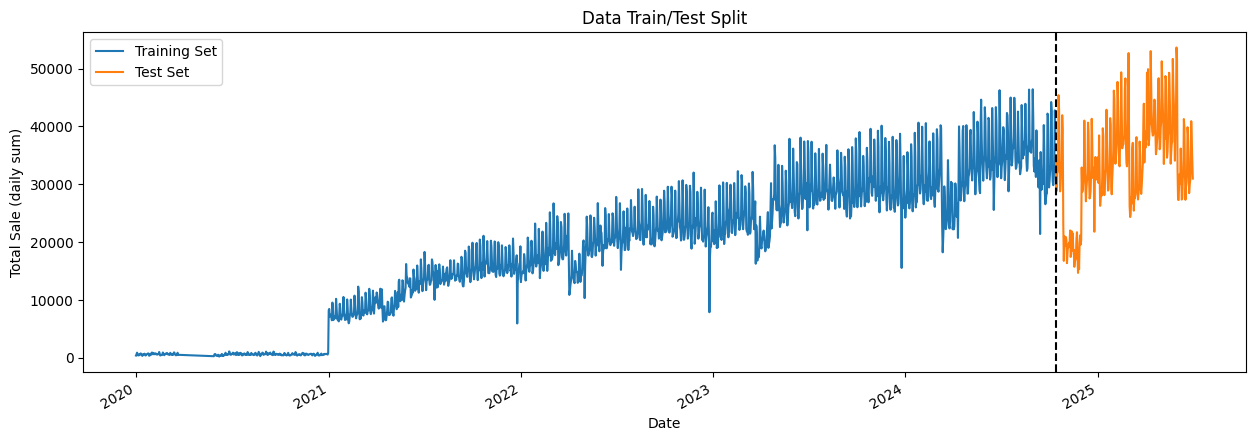

In [40]:
import matplotlib.pyplot as plt

# Aggregate total sale by date (sum across all branches per day)
daily_sales = df.groupby("Date")["Total Sale"].sum()

train_daily = daily_sales[daily_sales.index < split_date]
test_daily = daily_sales[daily_sales.index >= split_date]

fig, ax = plt.subplots(figsize=(15, 5))
train_daily.plot(ax=ax, label="Training Set")
test_daily.plot(ax=ax, label="Test Set")
ax.axvline(split_date, color="black", ls="--")
ax.legend(["Training Set", "Test Set"])
ax.set_title("Data Train/Test Split")
ax.set_ylabel("Total Sale (daily sum)")
plt.show()


In [21]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
print(categorical_cols)


[]


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baselines = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

baseline_results = []
for name, model in baselines.items():
    # ensure all features are numeric (coerce non-numeric -> NaN) and fill NA
    X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
    X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    baseline_results.append(
        {
            "Model": name,
            "MAE": mean_absolute_error(y_test, preds),
            "MSE": mean_squared_error(y_test, preds),
            "R2": r2_score(y_test, preds),
        }
    )

baseline_df = pd.DataFrame(baseline_results)
print(baseline_df)


              Model         MAE            MSE        R2
0  LinearRegression  323.550113  384750.424658 -0.396185
1      RandomForest  254.591278  156591.834171  0.431759
2  GradientBoosting  263.899033  147903.169037  0.463288


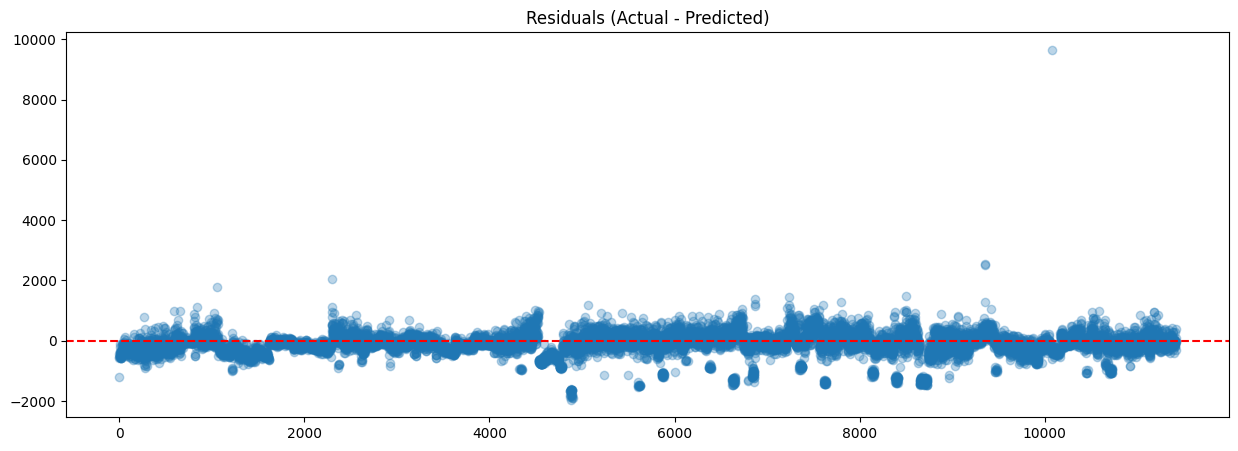

In [43]:
residuals = y_test.values - preds  # use your GradientBoosting preds

plt.figure(figsize=(15, 5))
plt.scatter(range(len(residuals)), residuals, alpha=0.3)
plt.axhline(0, color="red", ls="--")
plt.title("Residuals (Actual - Predicted)")
plt.show()


count    54144.000000
mean       764.713330
std        509.743103
min          0.000000
25%        395.042500
50%        691.045000
75%       1008.432500
max       8758.570000
Name: Total Sale, dtype: float64


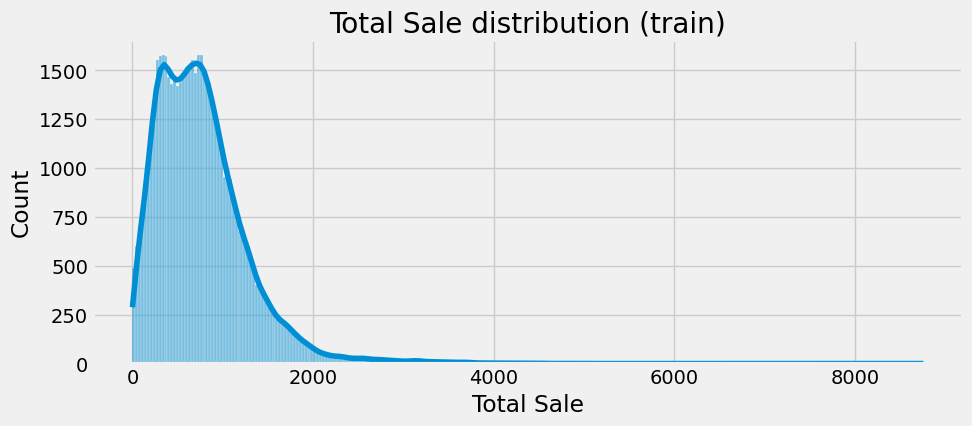

In [ ]:
print(y_train.describe())
plt.figure(figsize=(10, 4))
sns.histplot(y_train, kde=True)
plt.title("Total Sale distribution (train)")
plt.show()


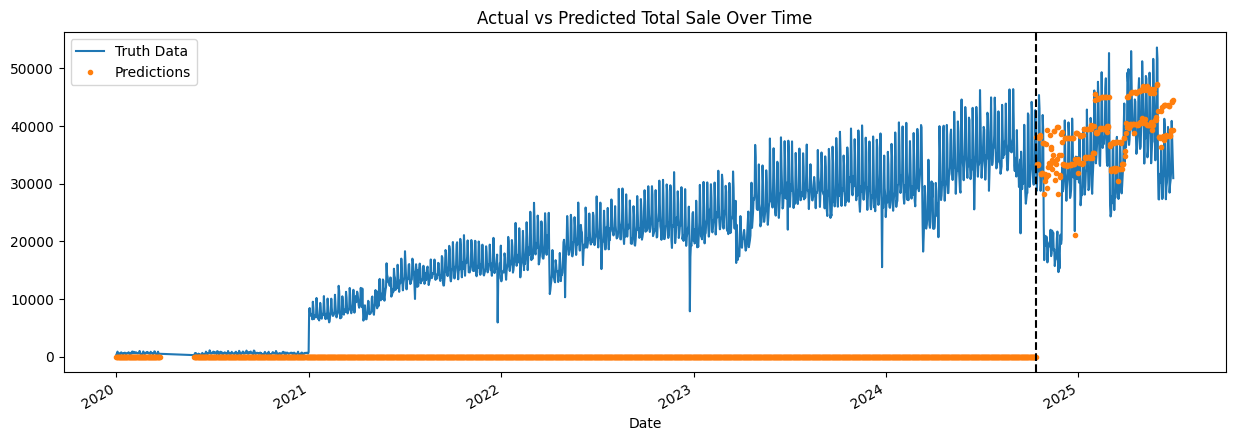

In [44]:
# Attach predictions to the test set
test = test.copy()
test["prediction"] = baselines["GradientBoosting"].predict(X_test)

# Merge predictions back into the full df, aligned by index
df_plot = df.merge(test[["prediction"]], how="left", left_index=True, right_index=True)

# Aggregate to daily totals (since you have multiple branches per day, like before)
daily_actual = df_plot.groupby("Date")["Total Sale"].sum()
daily_pred = df_plot.groupby("Date")["prediction"].sum()

fig, ax = plt.subplots(figsize=(15, 5))
daily_actual.plot(ax=ax, label="Truth Data")
daily_pred.plot(ax=ax, style=".", label="Predictions")
ax.axvline(split_date, color="black", ls="--")
ax.legend(["Truth Data", "Predictions"])
ax.set_title("Actual vs Predicted Total Sale Over Time")
plt.show()


In [26]:
print(df["Date"].min(), df["Date"].max())
print(df["Date"].dt.year.value_counts().sort_index())


2010-11-12 00:00:00 2025-06-30 00:00:00
Date
2010      109
2011     2658
2012     4191
2013     3814
2020      300
2021     8296
2022    11014
2023    14107
2024    14930
2025     8280
Name: count, dtype: int64


In [27]:
# Look at the actual suspicious rows
print(df[df["Date"].dt.year < 2023].head(20))
print(df[df["Date"].dt.year < 2023].shape)


    Day_of_Week       Date       Branch Name  Total Sale  population  \
970      Friday 2021-01-01  jojo's peri peri      214.05         228   
971    Saturday 2021-01-02  jojo's peri peri      292.18         228   
972      Sunday 2021-01-03  jojo's peri peri      179.51         228   
973      Monday 2021-01-04  jojo's peri peri      379.04         228   
974     Tuesday 2021-01-05  jojo's peri peri      136.87         228   
975   Wednesday 2021-01-06  jojo's peri peri      193.66         228   
976    Thursday 2021-01-07  jojo's peri peri      178.71         228   
977      Friday 2021-01-08  jojo's peri peri      308.28         228   
978    Saturday 2021-01-09  jojo's peri peri      161.98         228   
979      Sunday 2021-01-10  jojo's peri peri      183.13         228   
980      Monday 2021-01-11  jojo's peri peri       46.10         228   
981     Tuesday 2021-01-12  jojo's peri peri      193.75         228   
982   Wednesday 2021-01-13  jojo's peri peri      166.06        

In [28]:
branches_early = set(df[df["Date"].dt.year <= 2013]["Branch Name"].unique())
branches_late = set(df[df["Date"].dt.year >= 2020]["Branch Name"].unique())

print("Branches only in 2010-2013:", branches_early - branches_late)
print("Branches only in 2020-2025:", branches_late - branches_early)
print("Branches in both:", branches_early & branches_late)


Branches only in 2010-2013: {'pepes piri piri birmingham', 'pepes piri piri greenford', 'pepes piri piri fulham', 'pepes piri piri wembley', 'pepes piri piri kingston', 'pepes piri piri hendon', 'pepes piri piri harrow', 'pepes piri piri watford', 'pepes piri piri northampton', 'pepes piri piri luton', 'pepes piri piri burnt oak', 'pepes piri piri ladypool', 'pepes piri piri kilburn', 'pepes piri piri leicester', 'pepes piri piri manchester', 'pepes piri piri brick lane', 'pepes piri piri southall'}
Branches only in 2020-2025: {"jojo's peri peri", "rio's piri piri alum rock", "maeme's croydon", "maeme's bolton", "rio's piri piri bearwood", "maeme's leeds", "rio's piri piri holloway", "rio's piri piri watford", "rio's piri piri hemel hempstead", "rio's piri piri lisson grove", "rio's piri piri warrington", "rio's piri piri northampton", "rio's piri piri aston street", "rio's piri piri redditch", "maeme's bristol", "maeme's derby", "rio's piri piri sheldon", "rio's piri piri headington",